In [17]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

In [18]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])


In [19]:
def compute_cost (x, y, w, b):
    m = x.shape[0]
    cost = 0

    for i in range (m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i]) ** 2
    total_cost = 1 / (2 * m) * cost
    return total_cost
    

In [20]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range (m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb -y[i])
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

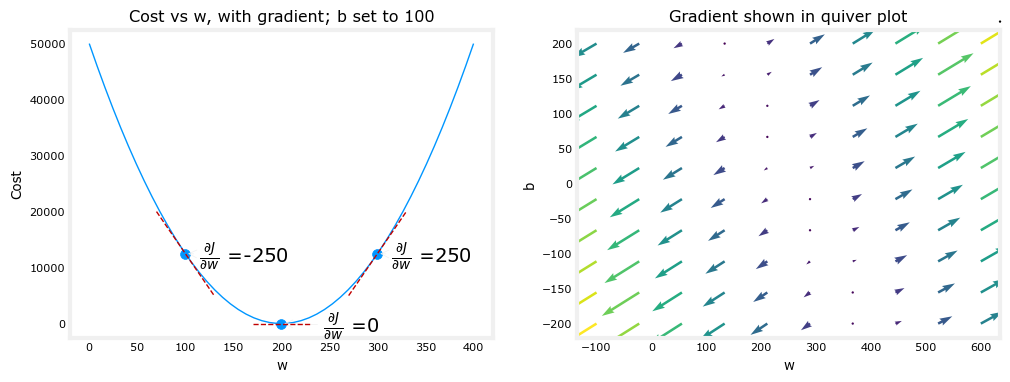

In [21]:
plt_gradients(x_train, y_train, compute_cost, compute_gredient)
plt.show()

In [22]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    """
    performs gradient descent fit w, b. updates w, b by talking 
    num_iters gradient steps with learning rate alpha 
    Args :
    x(ndarray (m,)) : data m examples 
    y(ndarray(m,)) : target value 
    w_in, b_in (scaler) : initial values of model parameters 
    alpha (float) : Learning rate
    num_iters (int) : number of iterations to run gradient descent
    cost function : function to call tonproduce cost
    gradient_function : function to call to gradient 

    Returns :
    w (scalar) : updated value of parameter after running gradient descent  
    b (scalar) : updated value of parameter after running gradient descent
    J_history (list) : history of cost value 
    P_history (list) : history of parameters [w, b]
    """
    # an array to store cost J w's at each iteration primerily for graphing later
    J_History = []
    P_history = []
    w = w_in
    b = b_in

    for i in (num_iters):
        #calculate the gradieint and update the parameter using gradient function
        dj_dw, dj_db = gradient_function(x, y, w, b)
        #update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        #save cost at each iteration
        if i< 100000:
            J_History.append(cost_function(x, y, w, b))
            P_history.append([w,b])
            
            if i% math.ceil (num_iters/10) == 0:
                print (f"iteration {i:4}, cost{J_History[-1]:0.2e}" , f"dj_dw :{dj_dw : 0.3e}, dj_db : {dj_db : 0.3e}" , 
                       f"w :{w : 0.5e} , b: {b : 0.5e}" )
    return w, b, J_History, P_history


In [23]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 1.0e-2 
w_final, b_final, J_hist, P_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gredient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

TypeError: 'int' object is not iterable